In [1]:
"""
Data_preprocessing.ipynb
Lukasz Radzinski
Charité Neurophysics Group, Berlin
Script for preprocessing single channel
MEG recordings
"""

'\nData_preprocessing.ipynb\nLukasz Radzinski\nCharité Neurophysics Group, Berlin\nScript for preprocessing single channel\nMEG recordings\n'

In [2]:
import os
import meet
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sig
import helper_scripts.helper_functions as helper_functions

# set global parameters for plots
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['savefig.dpi'] = 600

In [3]:
# select subject S1-S5

subject = 'S1'
additional_plot_title = ''

data_input_folder = '../Data/raw_data'
data_output_folder = '../Data/cleaned_data'
plots_output_folder = '../Results/preprocessing'

plots_output_folder = os.path.join(plots_output_folder, subject)

srate = 20000
unit = 'B [fT]'
asd_unit = '[fT/√HZ]'

In [4]:
# load data
raw_data = helper_functions.readMEG(os.path.join(data_input_folder, subject+'_MEG_stim.dat'), s_rate=srate, num_chans=2)

burst_prop_df = pd.read_csv('burst_subjects.csv')

lfreq_sigma = burst_prop_df[burst_prop_df['Subject']==subject]['Freq_start'].values[0]
rfreq_sigma = burst_prop_df[burst_prop_df['Subject']==subject]['Freq_end'].values[0]

burst_time_start = burst_prop_df[burst_prop_df['Subject']==subject]['Time_start'].values[0]
burst_time_end = burst_prop_df[burst_prop_df['Subject']==subject]['Time_end'].values[0]

In [5]:
# remove first 10 seconds of the recording
# as it can contain muscular artifacts
offset_start = 10*srate

MEG_raw_data = raw_data[0][offset_start:]
stimulus_data = raw_data[-1][offset_start:]

In [6]:
# add header to the plot function
def plt_header(main_title=''):

    title = 'Subject '+subject
    title += '\n'+main_title+additional_plot_title

    plt.title(title)

In [7]:
# show and save the plot function
def plt_show_save_fig(fig_name=None):

    if(fig_name):
        fig_name += '.png'
    else:
        plt_show_save_fig.counter += 1
        fig_name = 'Fig%02d.png' % plt_show_save_fig.counter

    print('--------------------\n'+fig_name)
    os.makedirs(plots_output_folder, exist_ok=True)
    plt.savefig(os.path.join(plots_output_folder, fig_name), bbox_inches='tight')
    plt.show()

plt_show_save_fig.counter = 0

--------------------
Fig01.png


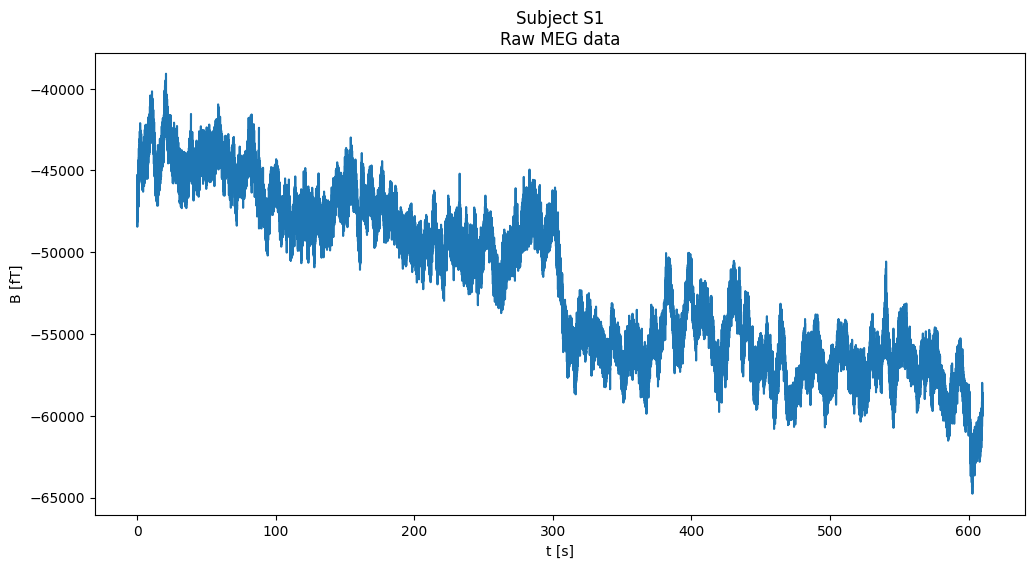

In [8]:
# plot the whole MEG signal

data = MEG_raw_data
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data

plt_header('Raw MEG data')
plt.plot(data_x, data_y)
plt.xlabel('t [s]')
plt.ylabel(unit)
plt_show_save_fig()

--------------------
Fig02.png


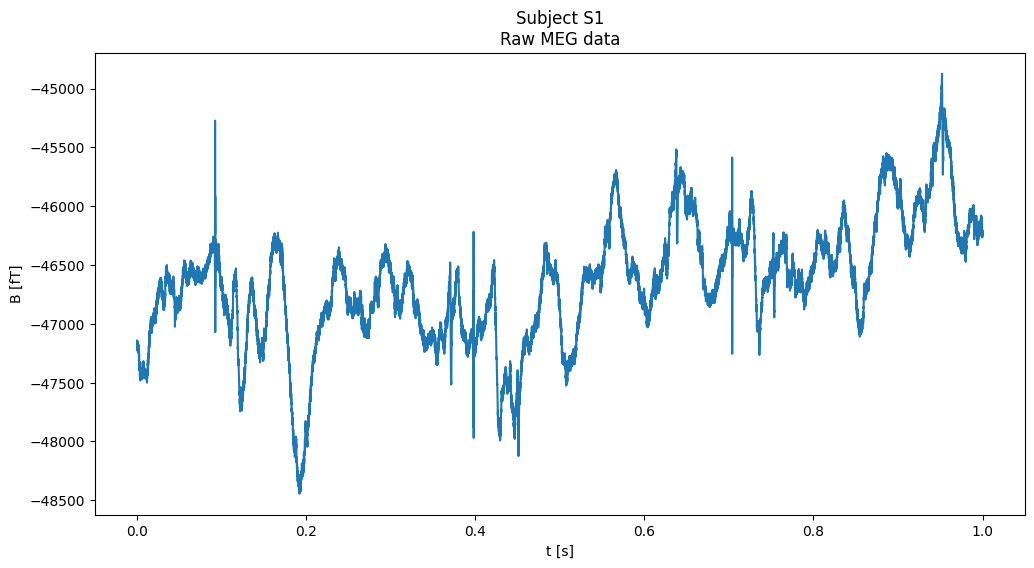

--------------------
Fig03.png


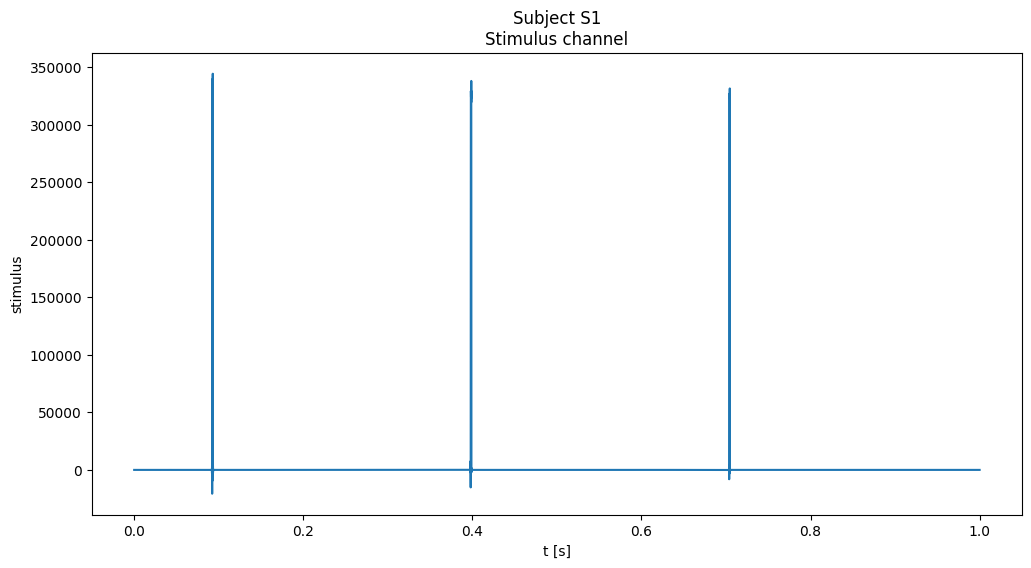

--------------------
Fig04.png


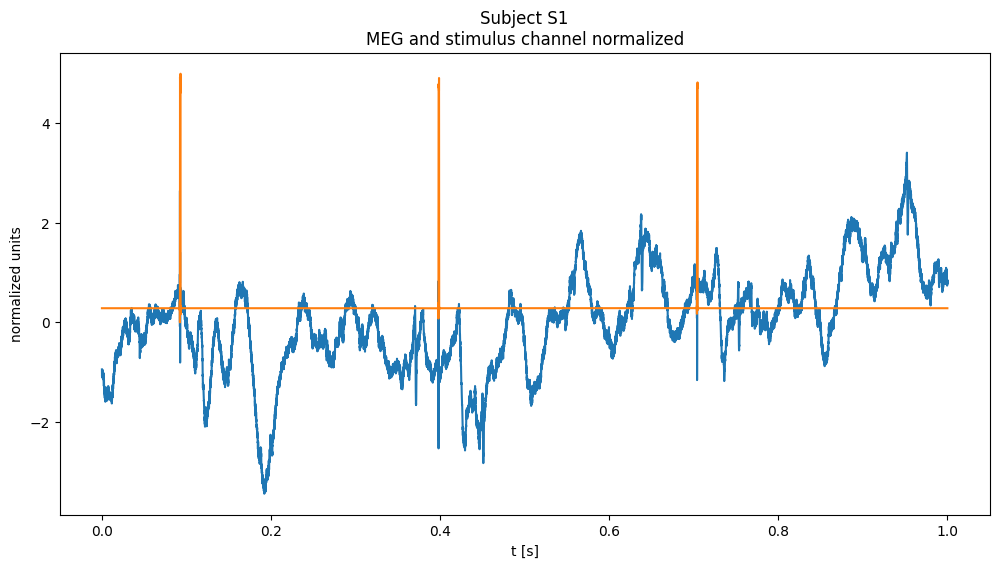

In [9]:
# plot MEG and stimulus signals

data = MEG_raw_data[:srate]
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data

plt_header('Raw MEG data')
plt.plot(data_x, data_y)
plt.xlabel('t [s]')
plt.ylabel(unit)
plt_show_save_fig()


data = stimulus_data[:srate]
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data

plt_header('Stimulus channel')
plt.plot(data_x, data_y)
plt.xlabel('t [s]')
plt.ylabel('stimulus')
plt_show_save_fig()


data = MEG_raw_data[:srate]
data = data - np.mean(data)
data = data / np.std(data)
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data

plt_header('MEG and stimulus channel normalized')
plt.plot(data_x, data_y, label='MEG channel')
plt.xlabel('t [s]')
plt.ylabel('stimulus')

data = stimulus_data[:srate]
data = data - np.min(data)
data = data / np.max(data)
data *= 5
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data

plt.plot(data_x, data_y, label='stimulus channel')
plt.xlabel('t [s]')
plt.ylabel('normalized units')
plt_show_save_fig()

In [10]:
# get the stimuli positions
all_stimuli = ((stimulus_data[1:]>250000) & (stimulus_data[:-1]<250000)).nonzero()[0]

# get the marker, omit the first and last (avoid edge effects)
marker = all_stimuli[1:-1]

In [11]:
# remove the stimuli

interpolate_win_ms = [-2, 2]
interpolate_win = np.round(np.array(interpolate_win_ms) / 1000. * srate).astype(int)
MEG_stimuli_removed_data = meet.interpolateEEG(MEG_raw_data.copy(), all_stimuli, interpolate_win)

interpolate_win_ms = [-3, 3]
interpolate_win = np.round(np.array(interpolate_win_ms) / 1000. * srate).astype(int)
MEG_stimuli_removed_data = meet.interpolateEEG(MEG_stimuli_removed_data, all_stimuli[1:], interpolate_win)

--------------------
Fig05.png


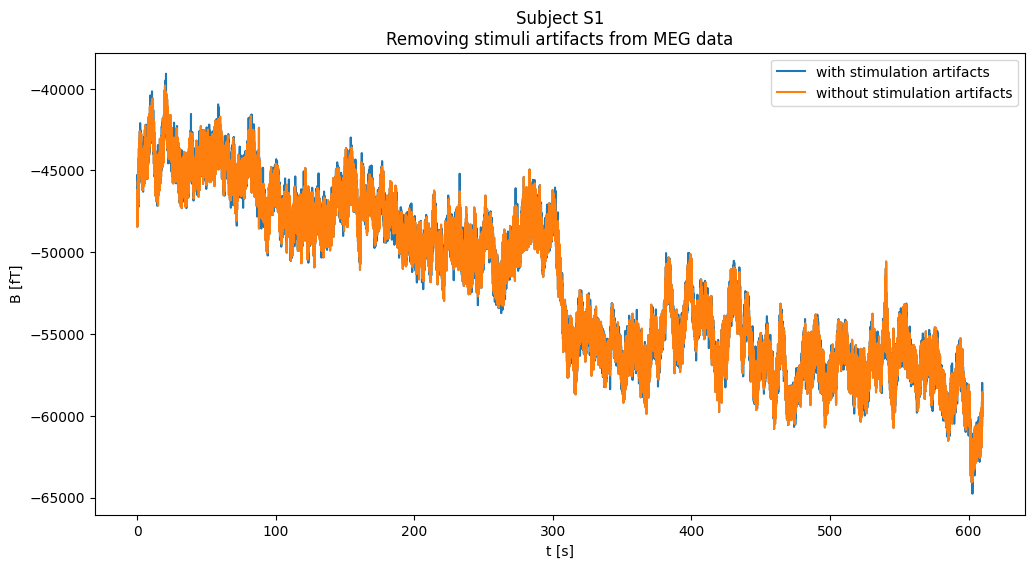

--------------------
Fig06.png


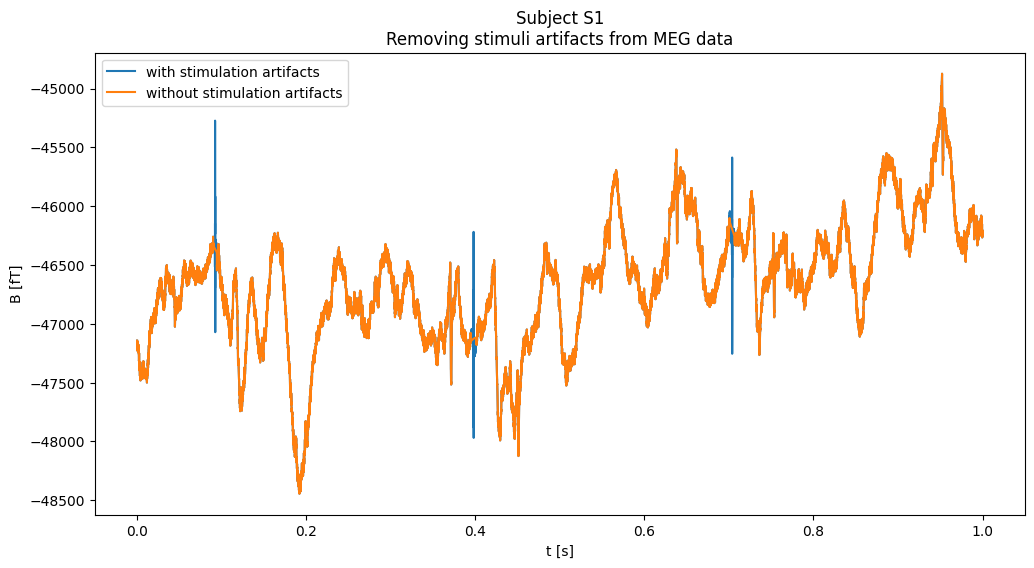

--------------------
Fig07.png


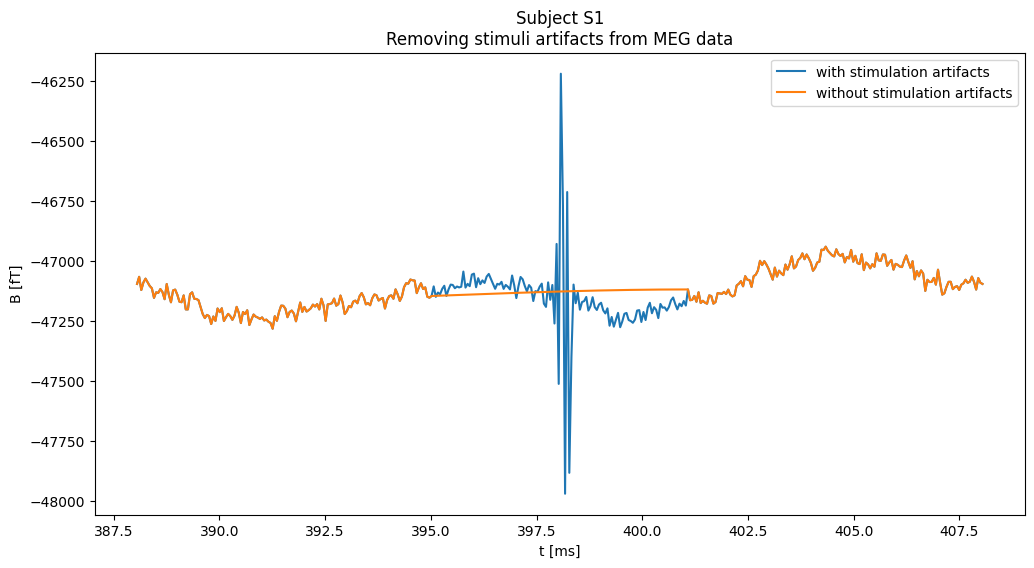

In [12]:
# plot signal without stimuli

data = MEG_raw_data
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data
plt.plot(data_x, data_y, label='with stimulation artifacts')

data = MEG_stimuli_removed_data
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data
plt.plot(data_x, data_y, label='without stimulation artifacts')

plt_header('Removing stimuli artifacts from MEG data')
plt.xlabel('t [s]')
plt.ylabel(unit)
plt.legend()
plt_show_save_fig()


data = MEG_raw_data[:srate]
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data
plt.plot(data_x, data_y, label='with stimulation artifacts')

data = MEG_stimuli_removed_data[:srate]
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data
plt.plot(data_x, data_y, label='without stimulation artifacts')

plt_header('Removing stimuli artifacts from MEG data')
plt.xlabel('t [s]')
plt.ylabel(unit)
plt.legend()
plt_show_save_fig()


start_time = marker[0]/srate - 0.01 
end_time = marker[0]/srate + 0.01

data = MEG_raw_data[int(start_time*srate):int(end_time*srate)]
data_x = np.linspace(start_time*1000, end_time*1000, len(data))
data_y = data
plt.plot(data_x, data_y, label='with stimulation artifacts')

data = MEG_stimuli_removed_data[int(start_time*srate):int(end_time*srate)]
data_x = np.linspace(start_time*1000, end_time*1000, len(data))
data_y = data
plt.plot(data_x, data_y, label='without stimulation artifacts')

plt_header('Removing stimuli artifacts from MEG data')
plt.xlabel('t [ms]')
plt.ylabel(unit)
plt.legend()
plt_show_save_fig()

In [13]:
# apply fc=0.1Hz hp filter to remove DC component

MEG_stimuli_removed_data = MEG_stimuli_removed_data - MEG_stimuli_removed_data.mean()

sos = sig.butter(4, 0.1, 'highpass', fs=srate, output='sos')
MEG_data = sig.sosfiltfilt(sos, MEG_stimuli_removed_data)

sos = sig.butter(4, 5000, 'lowpass', fs=srate, output='sos')
MEG_data = sig.sosfiltfilt(sos, MEG_data)

--------------------
Fig08.png


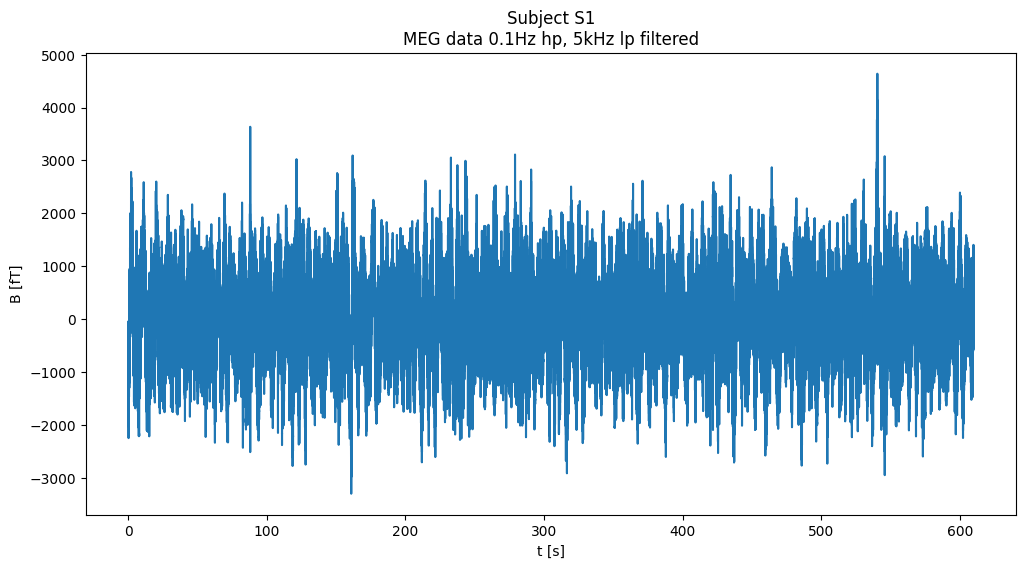

In [14]:
# plot signal without DC component

data = MEG_data
data_x = np.linspace(0, (len(data)-1)/srate, len(data))
data_y = data
plt.plot(data_x, data_y)

plt_header('MEG data 0.1Hz hp, 5kHz lp filtered')
plt.xlabel('t [s]')
plt.ylabel(unit)
plt_show_save_fig()

In [15]:
# calculate amplitude spectral density
def asd(data, nperseg):

    xf, yf = sig.welch(x=data, fs=srate, nperseg=nperseg)
    
    return xf, np.sqrt(yf)

--------------------
Fig09.png


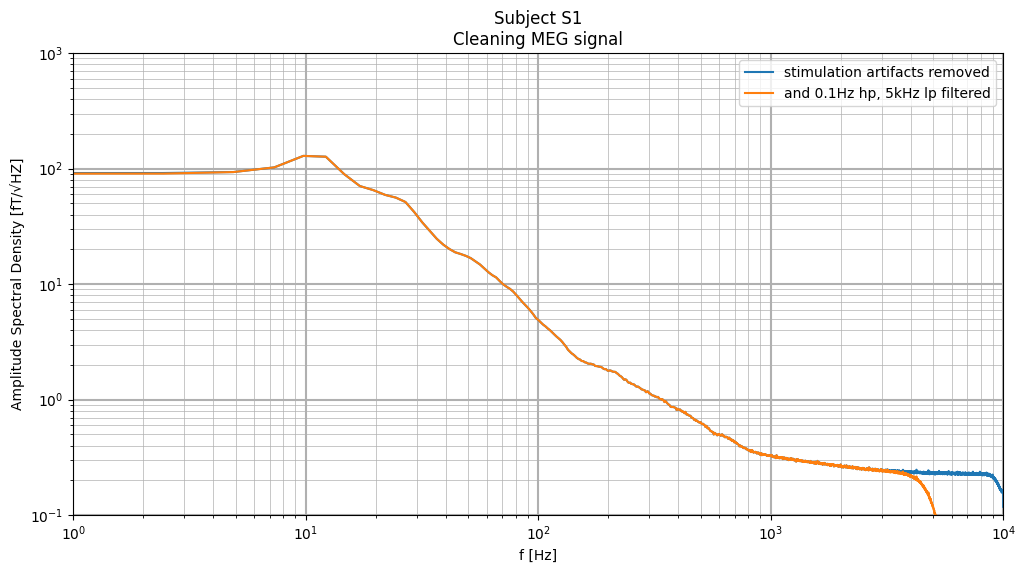

In [16]:
# plot asd of signal without powerline artifacts / spectrum peaks

plt_header('Cleaning MEG signal')

nperseg = 2**13

data = MEG_stimuli_removed_data
xf, yf = asd(data, nperseg)
plt.plot(xf, yf, label='stimulation artifacts removed')

data = MEG_data
xf, yf = asd(data, nperseg)
plt.plot(xf, yf, label='and 0.1Hz hp, 5kHz lp filtered')

plt.xscale('log')
plt.yscale('log')
plt.xlim((1,srate//2))
plt.ylim((0.1, 1000))
plt.xlabel('f [Hz]')
plt.ylabel('Amplitude Spectral Density %s' % asd_unit)
plt.legend()
plt.grid(axis='x', which='major', linewidth=1.5)
plt.grid(axis='x', which='minor', linewidth=0.5)
plt.grid(axis='y', which='major', linewidth=1.5)
plt.grid(axis='y', which='minor', linewidth=0.5)
plt_show_save_fig()

In [17]:
# apply band-pass filter to extract
# high-frequency band (sigma band)
# extend the band ±50Hz to obtain
# 3dB cutoff in the bandstop frequencies

sigma_fir_coeffs = sig.firwin(303, [lfreq_sigma-50, rfreq_sigma+50], pass_zero=False, fs=srate)
sigma_band_data = sig.filtfilt(sigma_fir_coeffs, 1.0, MEG_data)

In [18]:
# extract trials to remove outliers

whole_trial_len = int(np.round(np.mean(np.diff(all_stimuli))))
whole_trial_win_samples = [0,whole_trial_len]
whole_trial_t = (np.arange(whole_trial_win_samples[0], whole_trial_win_samples[1], 1)/float(srate)*1000)

broad_band_trials = meet.epochEEG(MEG_data, marker, whole_trial_win_samples)
sigma_band_trials = meet.epochEEG(sigma_band_data, marker, whole_trial_win_samples)

--------------------
Fig10.png


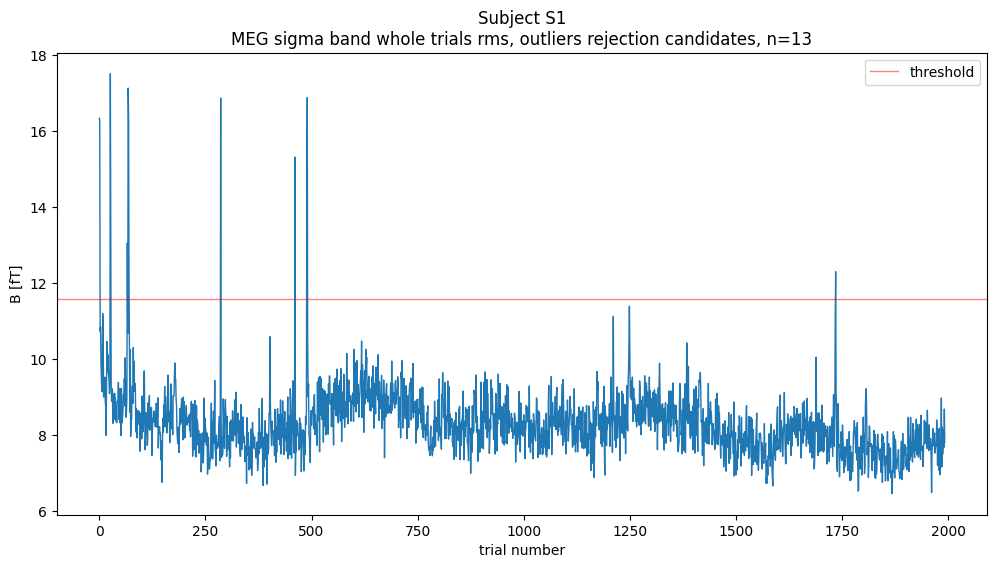

In [19]:
# calculate sigma band whole trials rms and percentiles to remove outliers
sigma_band_trials_rms = np.sqrt(np.mean(sigma_band_trials**2, axis=0))

sigma_band_rms_q25 = scipy.stats.scoreatpercentile(sigma_band_trials_rms, 25)
sigma_band_rms_q50 = np.median(sigma_band_trials_rms)
sigma_band_rms_q75 = scipy.stats.scoreatpercentile(sigma_band_trials_rms, 75)
sigma_band_rms_iqr = sigma_band_rms_q75 - sigma_band_rms_q25

# set a high threshold to remove only very outliers
threshold_sigma_band_rms = sigma_band_rms_q75 + 3*sigma_band_rms_iqr
not_outliers_sigma_band = sigma_band_trials_rms <= threshold_sigma_band_rms

data_y = sigma_band_trials_rms
plt.plot(np.clip(data_y, 0, 60), linewidth=1)
plt.axhline(threshold_sigma_band_rms, linewidth=1, alpha=0.5, color='red', label='threshold')

plt_header('MEG sigma band whole trials rms, outliers rejection candidates, n=%d' % np.sum(data_y > threshold_sigma_band_rms))
plt.xlabel('trial number')
plt.ylabel(unit)
plt.legend()
plt_show_save_fig()

--------------------
Fig11.png


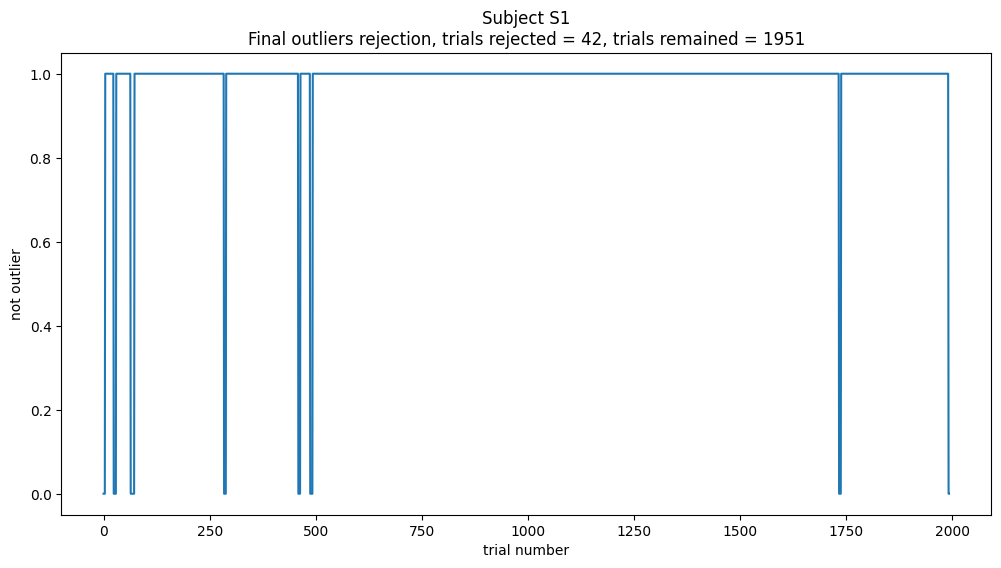

In [20]:
# final outliers estimation

not_outliers = not_outliers_sigma_band

not_outliers = np.convolve(not_outliers, np.ones(5)/5, mode='same')
not_outliers = (not_outliers > 0.999)

not_outliers_arr = []
temp_arr = []

last_value = False
for i in range(len(not_outliers)):
    if(not_outliers[i] == False and last_value == True):
        not_outliers_arr.append(temp_arr)
        temp_arr = []

    if(not_outliers[i] == True):
        temp_arr.append(i)
    
    last_value = not_outliers[i]


if(subject == 'S3'):
    # longer for more noisy signal
    not_outliers_len = 50
else:
    not_outliers_len = 20


for i in range(len(not_outliers_arr)):
    if(len(not_outliers_arr[i]) < not_outliers_len):
        not_outliers[not_outliers_arr[i]] = False

plt_header('Final outliers rejection, trials rejected = %d, trials remained = %d' % (np.sum(not_outliers == False), np.sum(not_outliers)))
plt.plot(not_outliers)
plt.xlabel('trial number')
plt.ylabel('not outlier')
plt_show_save_fig()

(6115, 1951)
(6115, 1951)
(1951,)
--------------------
Fig12.png


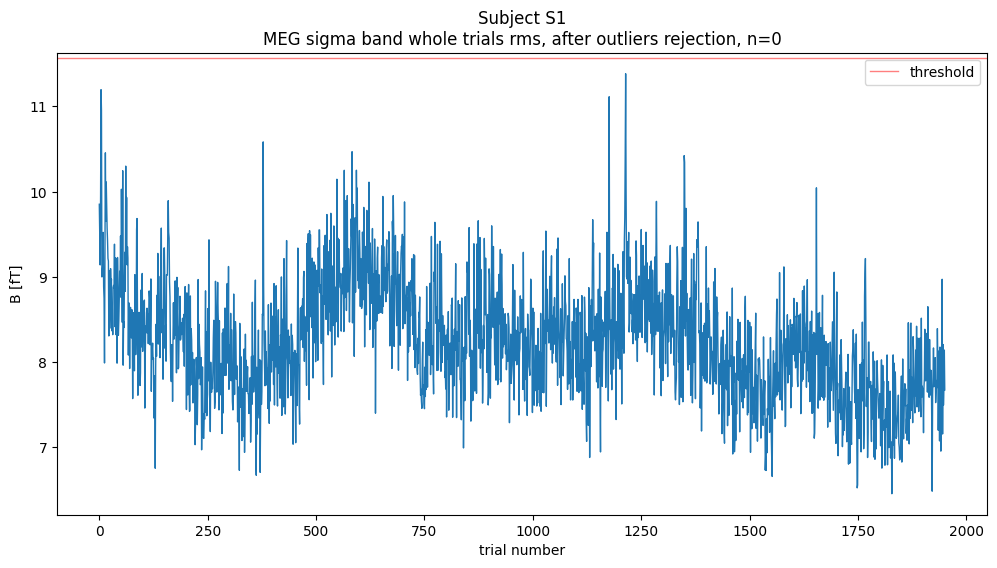

In [21]:
# reject outliers

broad_band_trials = broad_band_trials[:,not_outliers]
sigma_band_trials = sigma_band_trials[:,not_outliers]
sigma_band_trials_rms = sigma_band_trials_rms[not_outliers]

print(broad_band_trials.shape)
print(sigma_band_trials.shape)
print(sigma_band_trials_rms.shape)

data_y = sigma_band_trials_rms
plt.plot(np.clip(data_y, 0, 60), linewidth=1)
plt.axhline(threshold_sigma_band_rms, linewidth=1, alpha=0.5, color='red', label='threshold')

plt_header('MEG sigma band whole trials rms, after outliers rejection, n=%d' % np.sum(data_y > threshold_sigma_band_rms))
plt.xlabel('trial number')
plt.ylabel(unit)
plt.legend()
plt_show_save_fig()

In [22]:
# concatenate trials without outliers

MEG_data_no_outliers = np.concatenate(broad_band_trials.T)
all_stimuli_no_outliers = (np.arange(broad_band_trials.shape[1])*broad_band_trials.shape[0])
marker_no_outliers = all_stimuli_no_outliers[1:]
MEG_data_no_outliers = meet.interpolateEEG(MEG_data_no_outliers, marker_no_outliers, interpolate_win)

--------------------
Fig13.png


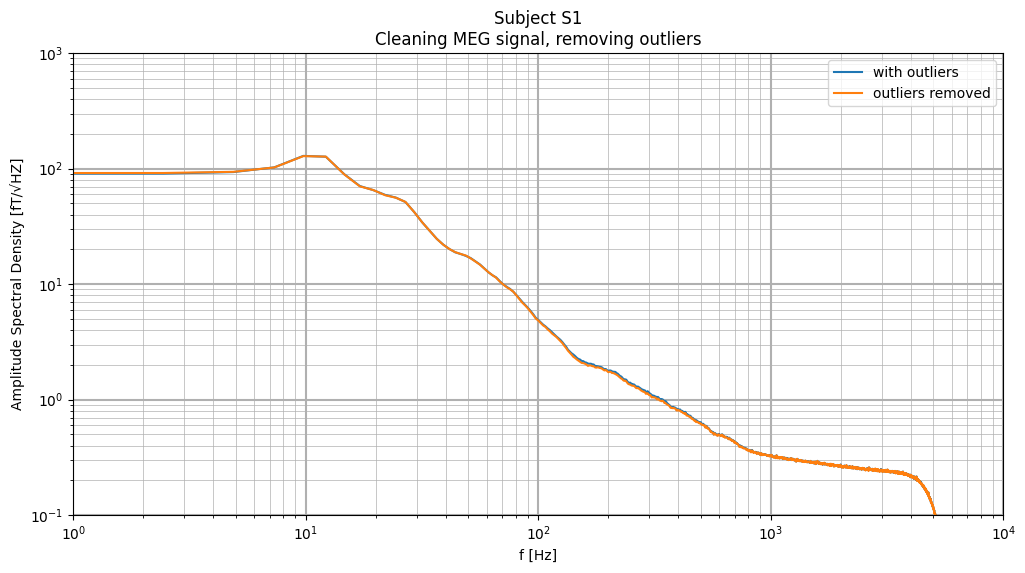

In [23]:
# plot asd of data with outliers removed

data = MEG_data
nperseg = 2**13
xf, yf = asd(data, nperseg)

plt_header('Cleaning MEG signal, removing outliers')
plt.plot(xf, yf, label='with outliers')

data = MEG_data_no_outliers
xf, yf = asd(data, nperseg)

plt.plot(xf, yf, label='outliers removed')
plt.xscale('log')
plt.yscale('log')
plt.xlim((1,srate//2))
plt.ylim((0.1, 1000))
plt.xlabel('f [Hz]')
plt.ylabel('Amplitude Spectral Density %s' % asd_unit)
plt.legend()
plt.grid(axis='x', which='major', linewidth=1.5)
plt.grid(axis='x', which='minor', linewidth=0.5)
plt.grid(axis='y', which='major', linewidth=1.5)
plt.grid(axis='y', which='minor', linewidth=0.5)
plt_show_save_fig()

In [24]:
MEG_data = MEG_data_no_outliers
all_stimuli = all_stimuli_no_outliers
marker = marker_no_outliers

--------------------
Fig14.png


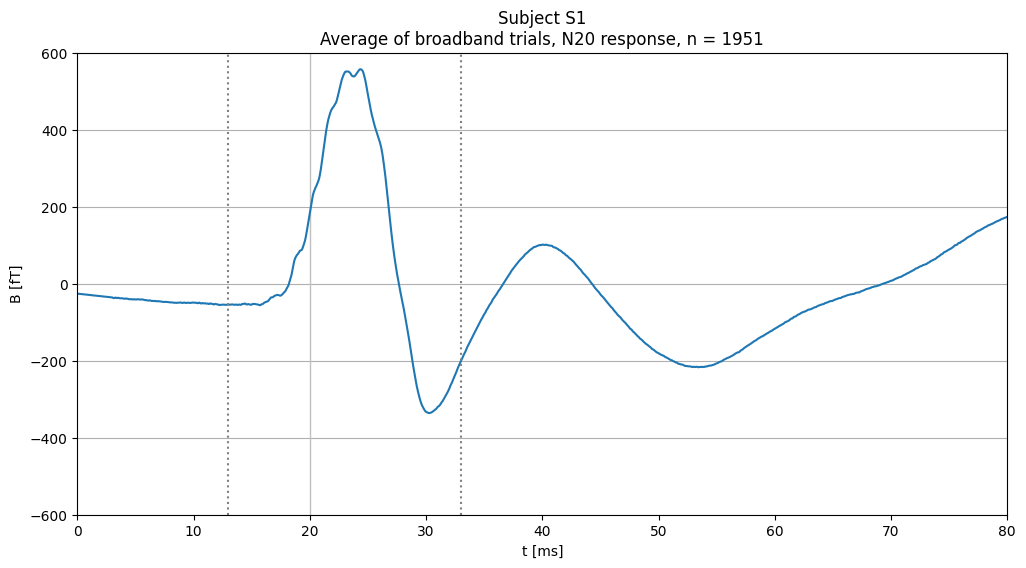

In [25]:
# plot broadband evoked response

data_y = broad_band_trials.mean(-1)

plt_header('Average of broadband trials, N20 response, n = %d' % len(broad_band_trials.T))
plt.axvline(20, linewidth=1, color='silver')
plt.plot(whole_trial_t, data_y)
plt.axvline(burst_time_start, color='gray', linestyle=':')
plt.axvline(burst_time_end, color='gray', linestyle=':')
plt.xlabel('t [ms]')
plt.ylabel(unit)
plt.ylim((-600, 600))
plt.xlim((0, 80))
plt.grid(axis='y')
plt_show_save_fig()

--------------------
Fig15.png


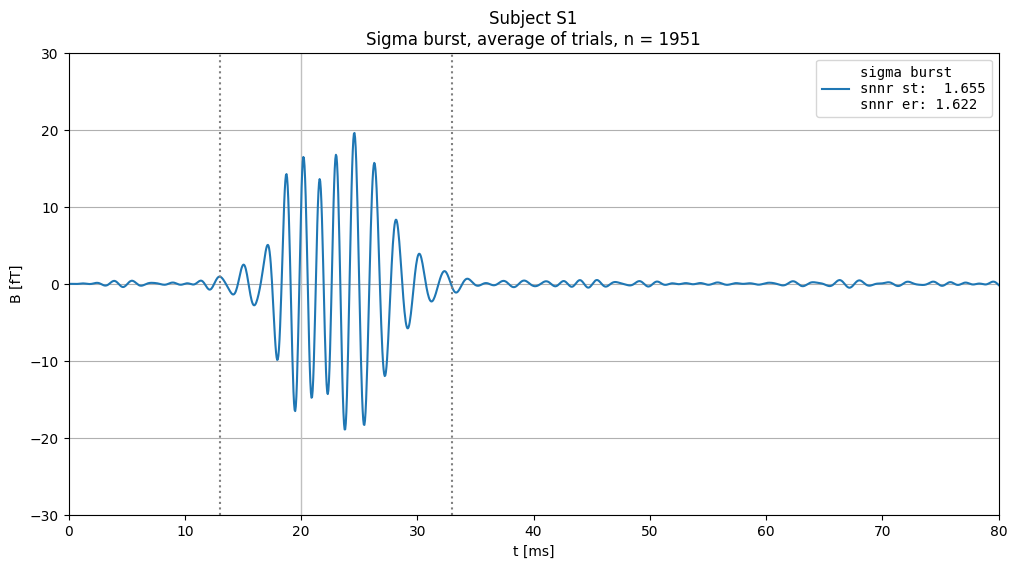

In [26]:
# plot sigma burst (high-frequency somatosensory evoked response)

sigma_band_trials_mean = np.mean(sigma_band_trials, axis=-1)

bts = burst_time_start
bte = burst_time_end

sigma_rms_st = np.sqrt(np.mean(sigma_band_trials[srate*bts//1000:srate*bte//1000]**2, axis=0))
noise_rms_st = np.sqrt(np.mean(sigma_band_trials[srate*50//1000:srate*80//1000]**2, axis=0))
snnr_st = np.mean(sigma_rms_st/noise_rms_st)

sigma_rms_er = np.sqrt(np.mean(sigma_band_trials[srate*bts//1000:srate*bte//1000]**2))
noise_rms_er = np.sqrt(np.mean(sigma_band_trials[srate*50//1000:srate*80//1000]**2))
snnr_er = sigma_rms_er/noise_rms_er

data_y = sigma_band_trials_mean

plt_header('Sigma burst, average of trials, n = %d' % len(sigma_band_trials.T))
plt.axvline(20, linewidth=1, color='silver')
plt.plot(whole_trial_t, data_y, label='sigma burst\nsnnr st: %6.3f\nsnnr er: %.3f' % (snnr_st, snnr_er))
plt.axvline(burst_time_start, color='gray', linestyle=':')
plt.axvline(burst_time_end, color='gray', linestyle=':')
plt.xlabel('t [ms]')
plt.ylabel(unit)
plt.ylim((-30, 30))
plt.xlim((0, 80))
plt.grid(axis='y')
plt.legend(prop={'family': 'DejaVu Sans Mono'})
plt_show_save_fig()

--------------------
Fig16.png


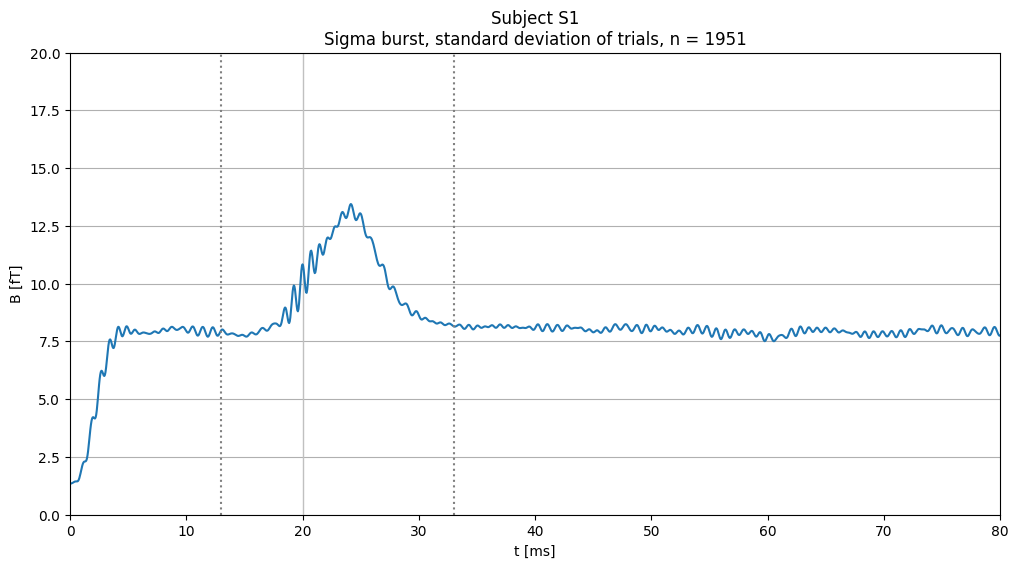

In [27]:
# plot sigma burst (high-frequency somatosensory evoked response)

data_y = sigma_band_trials.std(-1)

plt_header('Sigma burst, standard deviation of trials, n = %d' % len(sigma_band_trials.T))
plt.axvline(20, linewidth=1, color='silver')
plt.plot(whole_trial_t, data_y)
plt.axvline(burst_time_start, color='gray', linestyle=':')
plt.axvline(burst_time_end, color='gray', linestyle=':')
plt.xlabel('t [ms]')
plt.ylabel(unit)
plt.ylim((0, 20))
plt.xlim((0, 80))
plt.grid(axis='y')
plt_show_save_fig()

--------------------
Fig17.png


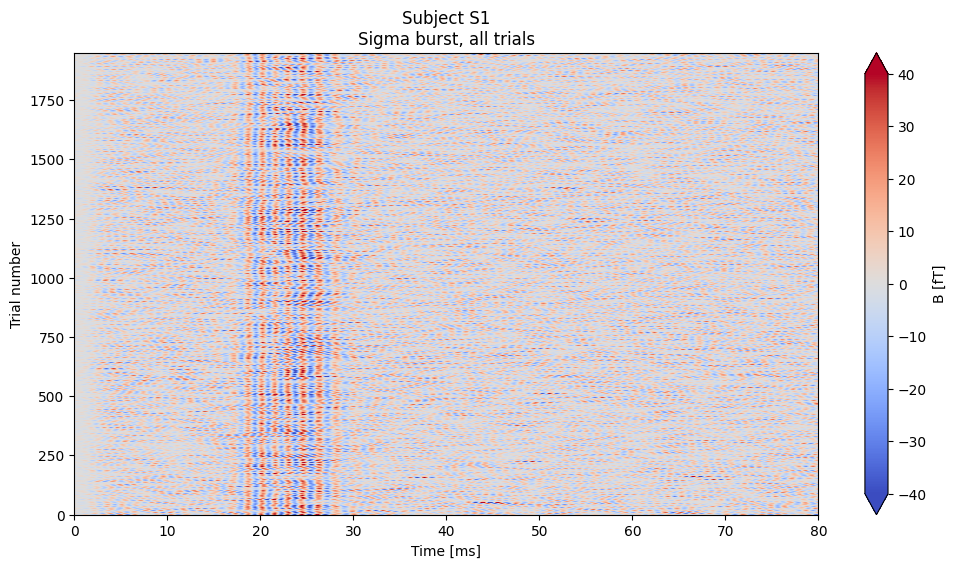

--------------------
Fig18.png


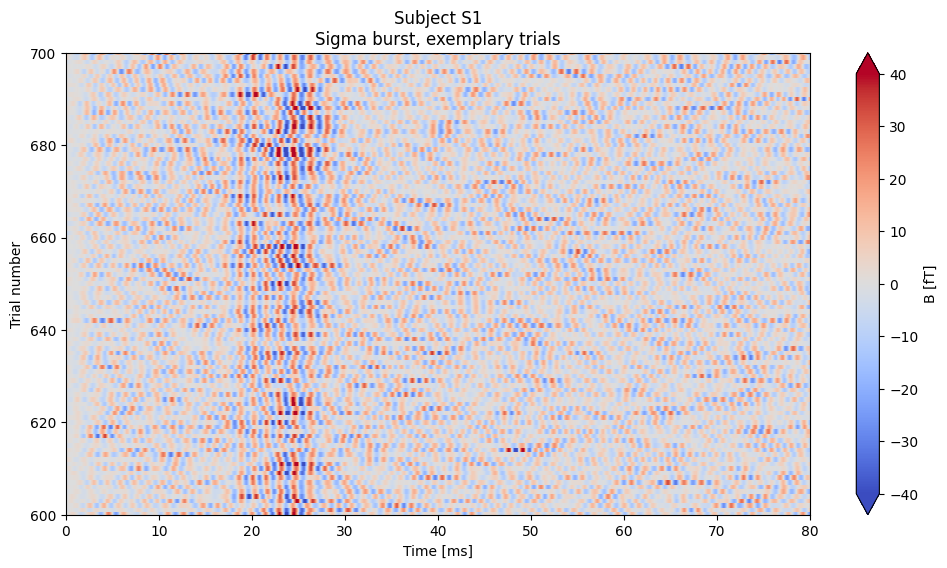

In [28]:
# plot sigma burst single trials stack on each other

plt.rcParams['image.cmap'] = 'coolwarm'

plt_header('Sigma burst, all trials')
data = sigma_band_trials

limit = 40
plt.pcolormesh(whole_trial_t, np.arange(len(data.T)), data.T, vmin=-limit, vmax=limit)
plt.ylabel('Trial number')
plt.xlabel('Time [ms]')
plt.xlim(0,80)
clb = plt.colorbar(extend='both')
clb.set_label(unit)
plt_show_save_fig()

start_trial = 600
end_trial = 700
plt_header('Sigma burst, exemplary trials')
data = sigma_band_trials

limit = 40
plt.pcolormesh(whole_trial_t, np.arange(len(data.T)), data.T, vmin=-limit, vmax=limit)
plt.ylabel('Trial number')
plt.xlabel('Time [ms]')
plt.xlim(0,80)
plt.ylim(start_trial,end_trial)
clb = plt.colorbar(extend='both')
clb.set_label(unit)
plt_show_save_fig()

In [29]:
# save the preprocessed data

stimulus_new = np.zeros(len(MEG_data))
stimulus_new[marker_no_outliers] = 1.0

out_data = np.stack((MEG_data, stimulus_new))
os.makedirs(data_output_folder, exist_ok=True)
np.save(os.path.join(data_output_folder, subject+'.npy'), out_data)